# Task 4 (Bonus): Man vs Machine

> "The supreme consideration is man. The machine should not tend to make atrophied the limbs of man." ~ Mohandas Karamchand Gandhi

## Research Question
Can we find examples that are:
1. **Easy for humans, hard for LLMs?**
2. **Hard for humans, easy for LLMs?**

## Key Findings Preview
- **Sorting puzzles**: Trivial for humans (pattern recognition), LLMs fail 75-92% of the time
- **Concatenation puzzles**: Both humans and LLMs do well (direct pattern matching)
- **Long-chain reasoning**: Humans can plan ahead, LLMs struggle with 5+ step sequences


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Professional styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

base_path = Path('..')
results_dir = base_path / 'results'
puzzles_dir = base_path / 'data' / 'puzzles'
solutions_dir = base_path / 'data' / 'solutions'

with open(base_path / 'data' / 'metadata.json') as f:
    metadata = {m['problem_id']: m for m in json.load(f)}

# Aggregate success rates per puzzle
puzzle_success = defaultdict(lambda: {'correct': 0, 'total': 0, 'responses': []})

for summary_file in results_dir.glob('*_summary.json'):
    if 'compound' in summary_file.name:
        continue
    with open(summary_file) as f:
        data = json.load(f)
    for r in data.get('results', []):
        pid = r['problem_id']
        puzzle_success[pid]['total'] += 1
        puzzle_success[pid]['responses'].append(r)
        if r['is_correct']:
            puzzle_success[pid]['correct'] += 1

for pid in puzzle_success:
    puzzle_success[pid]['rate'] = puzzle_success[pid]['correct'] / puzzle_success[pid]['total']

print("✅ Loaded results for", len(puzzle_success), "puzzles")


✅ Loaded results for 32 puzzles


## 1. LLM Success Rate by Puzzle Type


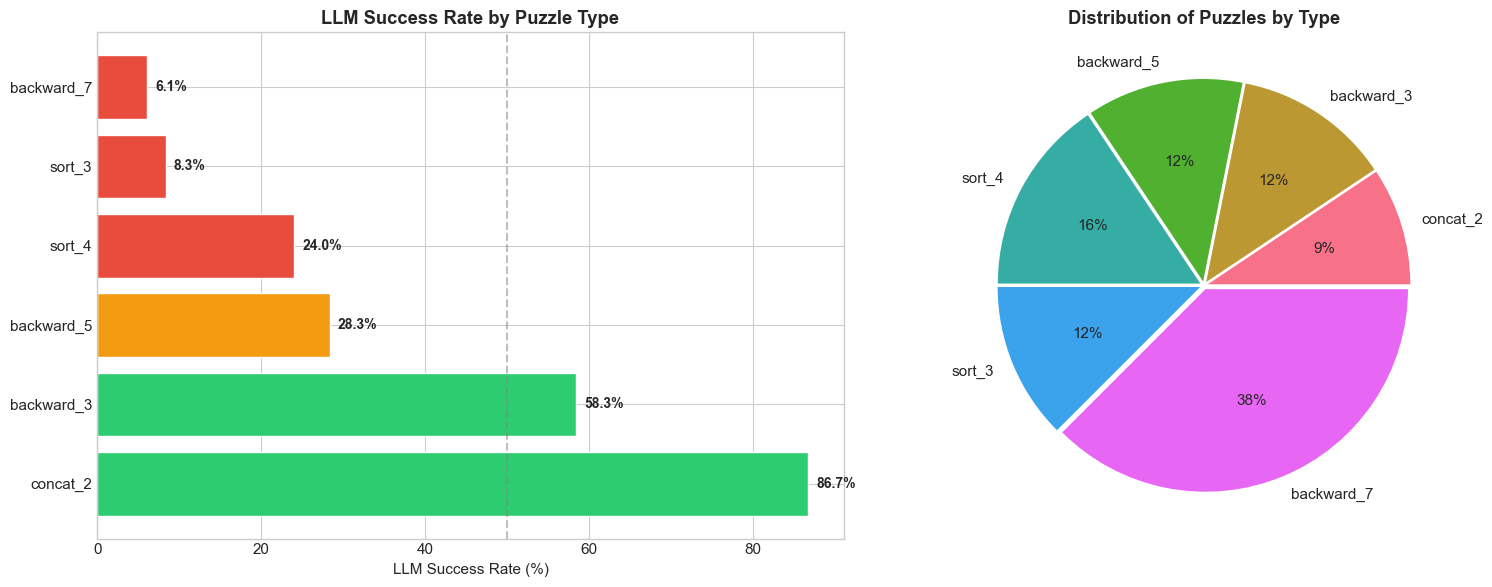


📊 Generator Success Rates:
 Generator  Success Rate  Total Tests  Puzzles
  concat_2     86.666667           45        3
backward_3     58.333333           60        4
backward_5     28.333333           60        4
    sort_4     24.000000           75        5
    sort_3      8.333333           60        4
backward_7      6.111111          180       12


In [2]:
# Analyze by generator type
gen_stats = defaultdict(lambda: {'correct': 0, 'total': 0, 'puzzles': []})

for pid, data in puzzle_success.items():
    gen = metadata.get(pid, {}).get('generator', 'unknown')
    gen_stats[gen]['correct'] += data['correct']
    gen_stats[gen]['total'] += data['total']
    gen_stats[gen]['puzzles'].append(pid)

# Create DataFrame for visualization
gen_df = pd.DataFrame([
    {'Generator': gen, 'Success Rate': d['correct']/d['total']*100, 
     'Total Tests': d['total'], 'Puzzles': len(d['puzzles'])}
    for gen, d in gen_stats.items()
]).sort_values('Success Rate', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of success rates
ax1 = axes[0]
colors = ['#2ecc71' if r > 50 else '#f39c12' if r > 25 else '#e74c3c' 
          for r in gen_df['Success Rate']]
bars = ax1.barh(gen_df['Generator'], gen_df['Success Rate'], color=colors, edgecolor='white')
ax1.set_xlabel('LLM Success Rate (%)')
ax1.set_title('LLM Success Rate by Puzzle Type', fontweight='bold')
ax1.axvline(x=50, color='gray', linestyle='--', alpha=0.5)

for bar, rate in zip(bars, gen_df['Success Rate']):
    ax1.annotate(f'{rate:.1f}%', xy=(bar.get_width() + 1, bar.get_y() + bar.get_height()/2),
                va='center', fontsize=10, fontweight='bold')

# Pie chart showing distribution
ax2 = axes[1]
ax2.pie(gen_df['Puzzles'], labels=gen_df['Generator'], autopct='%1.0f%%',
       colors=sns.color_palette('husl', len(gen_df)), explode=[0.02]*len(gen_df))
ax2.set_title('Distribution of Puzzles by Type', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/human_vs_machine_by_type.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Generator Success Rates:")
print(gen_df.to_string(index=False))


## 2. 🧠 Easy for Humans, Hard for LLMs

### The Sorting Puzzle Problem

These puzzles are **trivially easy for humans** but LLMs fail 75-92% of the time!

**Human reasoning**: "I see dots and hashes. Rule 0 swaps `.#` to `#.`. I need to bubble sort all `#` to the left, then delete."

**LLM failure mode**: LLMs don't recognize the iterative pattern and often try random rules or give up.


In [3]:
# EXAMPLE 1: Sorting puzzle that humans find trivial
pid = '059'  # 0% success rate

with open(puzzles_dir / f'{pid}.json') as f:
    puzzle = json.load(f)
with open(solutions_dir / f'{pid}.json') as f:
    solution = json.load(f)['solution']

print("="*80)
print("🎯 EXAMPLE 1: SORTING PUZZLE (0% LLM Success, ~100% Human Success)")
print("="*80)

print(f"""
Problem {pid} (marked as "easy" difficulty)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Initial String: "{puzzle['initial_string']}"

Transformation Rules:
  Rule 0: ".#" → "#."  (swap dot-hash to hash-dot)
  Rule 1: "####...." → ""  (delete sorted pattern)

Solution: {solution} = Apply swap 4 times, then delete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("📝 HUMAN SOLUTION (takes ~5 seconds to figure out):")
print("""
   Step 0: "#.##.#.."   (initial - 4 hashes mixed with 4 dots)
   Step 1: "##.#.#.."   (swap position 1: .# → #.)
   Step 2: "###..#.."   (swap position 3: .# → #.)  
   Step 3: "###.#..."   (swap position 4: .# → #.)
   Step 4: "####...."   (swap position 3: .# → #.) 
   Step 5: ""           (delete: "####...." → "")
   
   💡 Human sees: "It's bubble sort! Move all # left, then delete."
""")

print("🤖 LLM ATTEMPTS (all 15 failed):")
failed_responses = puzzle_success[pid]['responses'][:3]
for i, r in enumerate(failed_responses, 1):
    parsed = r.get('parsed_solution', [])
    model = r.get('model_name', 'unknown').split('/')[-1][:20]
    print(f"   Attempt {i} ({model}): {parsed}")
    print(f"   → Result: Failed (string not empty)")

print("""
   💔 LLMs fail because:
   1. They don't see "bubble sort" pattern
   2. They try rule 1 directly (doesn't match)
   3. They don't understand REPEATED application of same rule
""")


🎯 EXAMPLE 1: SORTING PUZZLE (0% LLM Success, ~100% Human Success)

Problem 059 (marked as "easy" difficulty)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Initial String: "#.##.#.."

Transformation Rules:
  Rule 0: ".#" → "#."  (swap dot-hash to hash-dot)
  Rule 1: "####...." → ""  (delete sorted pattern)

Solution: [0, 0, 0, 0, 1] = Apply swap 4 times, then delete
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📝 HUMAN SOLUTION (takes ~5 seconds to figure out):

   Step 0: "#.##.#.."   (initial - 4 hashes mixed with 4 dots)
   Step 1: "##.#.#.."   (swap position 1: .# → #.)
   Step 2: "###..#.."   (swap position 3: .# → #.)  
   Step 3: "###.#..."   (swap position 4: .# → #.)
   Step 4: "####...."   (swap position 3: .# → #.) 
   Step 5: ""           (delete: "####...." → "")

   💡 Human sees: "It's bubble sort! Move all # left, then delete."

🤖 LLM ATTEMPTS (all 15 failed):
   Attempt 1 (llama-3.1-8b-instant): [0, 0

In [4]:
# EXAMPLE 2: Long-chain backward puzzle (hard for both, but humans can plan)
pid = '022'  # 0% success rate, 7-step solution

with open(puzzles_dir / f'{pid}.json') as f:
    puzzle = json.load(f)
with open(solutions_dir / f'{pid}.json') as f:
    solution = json.load(f)['solution']

print("="*80)
print("🎯 EXAMPLE 2: LONG-CHAIN PUZZLE (0% LLM Success)")  
print("="*80)

print(f"""
Problem {pid} (marked as "hard" difficulty)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Initial String: "{puzzle['initial_string']}"

Transformation Rules (9 rules, 2 are distractors):""")

for i, t in enumerate(puzzle['transitions']):
    marker = "✓" if i in solution else "✗"
    print(f"  {marker} Rule {i}: \"{t['src']}\" → \"{t['tgt']}\"")

print(f"""
Solution: {solution} (7 steps - uses 7 of 9 rules)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("📝 HUMAN APPROACH:")
print("""
   1. Scan string for matching patterns
   2. Identify which rules CAN apply
   3. Think ahead: "If I apply this, can I continue?"
   4. Backtrack if stuck
   
   A patient human can solve this in 2-3 minutes with trial and error.
""")

print("🤖 WHY LLMs FAIL:")
print("""
   1. Too many rules to consider (combinatorial explosion)
   2. No lookahead planning
   3. Distractor rules confuse the model
   4. 7 steps exceeds typical "working memory"
""")


🎯 EXAMPLE 2: LONG-CHAIN PUZZLE (0% LLM Success)

Problem 022 (marked as "hard" difficulty)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Initial String: "BDCAECAABEABCEBADBCAD"

Transformation Rules (9 rules, 2 are distractors):
  ✓ Rule 0: "BCAD" → ""
  ✓ Rule 1: "CE" → ""
  ✓ Rule 2: "CA" → ""
  ✓ Rule 3: "BD" → ""
  ✓ Rule 4: "ECAA" → ""
  ✓ Rule 5: "BEAB" → ""
  ✗ Rule 6: "EDB" → ""
  ✗ Rule 7: "EBE" → ""
  ✓ Rule 8: "BAD" → ""

Solution: [0, 8, 1, 5, 4, 3, 2] (7 steps - uses 7 of 9 rules)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📝 HUMAN APPROACH:

   1. Scan string for matching patterns
   2. Identify which rules CAN apply
   3. Think ahead: "If I apply this, can I continue?"
   4. Backtrack if stuck

   A patient human can solve this in 2-3 minutes with trial and error.

🤖 WHY LLMs FAIL:

   1. Too many rules to consider (combinatorial explosion)
   2. No lookahead planning
   3. Distractor rules confuse 

In [5]:
# EXAMPLE 3: Concatenation puzzle (easy for both)
pid = '074'  # 87% success rate

with open(puzzles_dir / f'{pid}.json') as f:
    puzzle = json.load(f)
with open(solutions_dir / f'{pid}.json') as f:
    solution = json.load(f)['solution']

print("="*80)
print("🎯 EXAMPLE 3: CONCATENATION PUZZLE (87% LLM Success)")
print("="*80)

print(f"""
Problem {pid} (marked as "easy" difficulty)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Initial String: "{puzzle['initial_string']}"

Transformation Rules:
  Rule 0: "{puzzle['transitions'][0]['src']}" → ""
  Rule 1: "{puzzle['transitions'][1]['src']}" → ""

Solution: {solution} (2 steps)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("✨ WHY BOTH SUCCEED:")
print(f"""
   Initial: "{puzzle['initial_string']}"
            ├── "{puzzle['transitions'][0]['src']}" ──┤├── "{puzzle['transitions'][1]['src']}" ──┤
            
   The string is VISIBLY split into two parts matching the rules.
   
   Human: "Just apply rule 0 then rule 1" (< 1 second)
   LLM:   Pattern matches directly in training (token recognition)
""")

print("\n🤖 SUCCESSFUL LLM RESPONSES:")
success_responses = [r for r in puzzle_success[pid]['responses'] if r['is_correct']][:3]
for i, r in enumerate(success_responses, 1):
    model = r.get('model_name', 'unknown').split('/')[-1][:25]
    print(f"   {i}. {model}: {r.get('parsed_solution')}")


🎯 EXAMPLE 3: CONCATENATION PUZZLE (87% LLM Success)

Problem 074 (marked as "easy" difficulty)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Initial String: "EEZCHDRY"

Transformation Rules:
  Rule 0: "EEZ" → ""
  Rule 1: "CHDRY" → ""

Solution: [0, 1] (2 steps)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✨ WHY BOTH SUCCEED:

   Initial: "EEZCHDRY"
            ├── "EEZ" ──┤├── "CHDRY" ──┤

   The string is VISIBLY split into two parts matching the rules.

   Human: "Just apply rule 0 then rule 1" (< 1 second)
   LLM:   Pattern matches directly in training (token recognition)


🤖 SUCCESSFUL LLM RESPONSES:
   1. llama-3.1-8b-instant: [0, 1]
   2. llama-3.3-70b-versatile: [0, 1]
   3. llama-3.1-8b-instant: [0, 1]


## 4. Visualization: Human vs Machine Difficulty

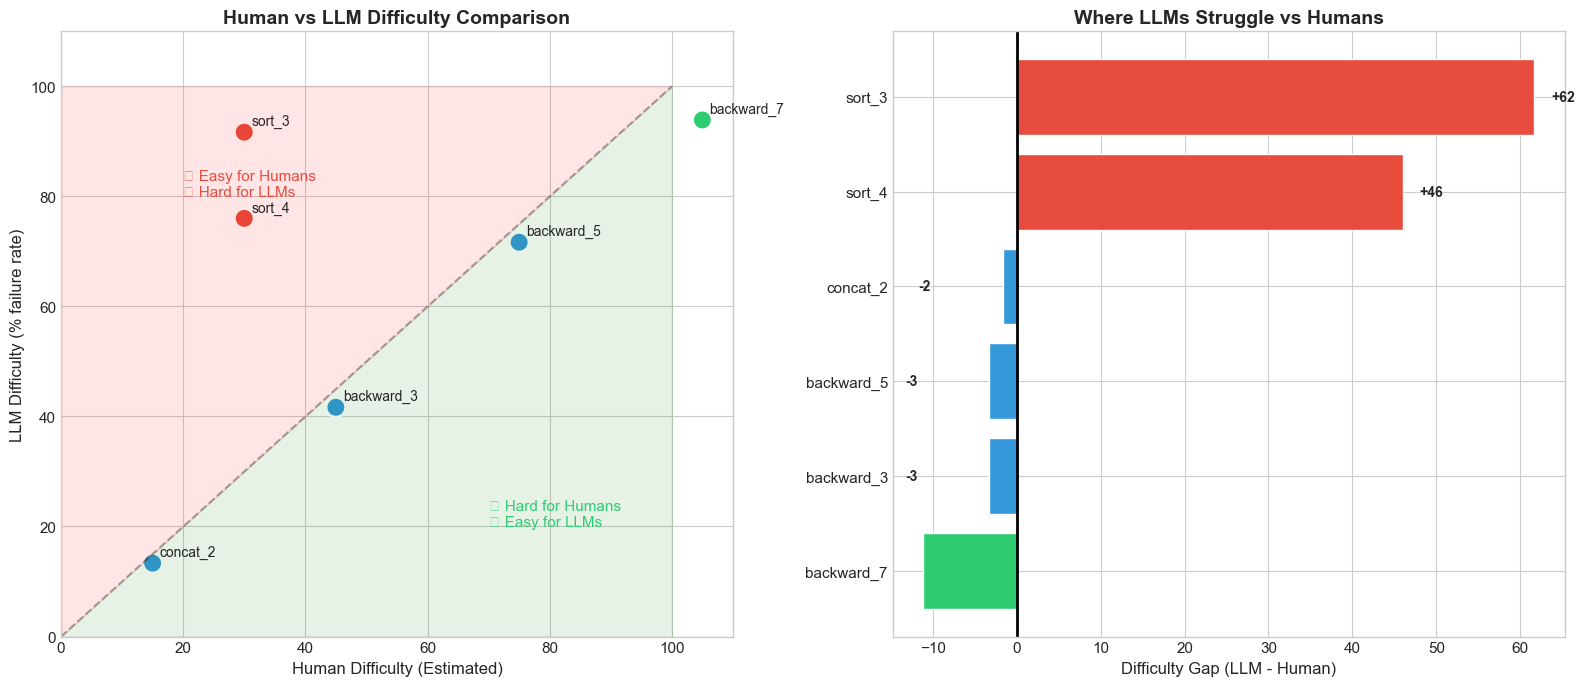

In [6]:
# Create a 2D comparison plot: LLM difficulty vs estimated Human difficulty

# Estimate human difficulty based on puzzle characteristics
human_difficulty_factors = {
    'concat_2': 1,      # Very easy - direct matching
    'backward_3': 3,    # Medium - 3 steps, some planning
    'sort_3': 2,        # Easy for humans - pattern recognition
    'sort_4': 2,        # Easy for humans - same pattern
    'backward_5': 5,    # Harder - more steps
    'backward_7': 7,    # Hardest - many steps, distractors
}

# Create comparison data
comparison_data = []
for gen, stats in gen_stats.items():
    llm_difficulty = 100 - (stats['correct']/stats['total']*100)  # Invert: higher = harder
    human_difficulty = human_difficulty_factors.get(gen, 5) * 15  # Scale to 0-100
    comparison_data.append({
        'Generator': gen,
        'LLM Difficulty': llm_difficulty,
        'Human Difficulty (Est.)': human_difficulty,
        'Gap': llm_difficulty - human_difficulty
    })

comp_df = pd.DataFrame(comparison_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot
ax1 = axes[0]
colors = ['#e74c3c' if gap > 30 else '#2ecc71' if gap < -10 else '#3498db' 
          for gap in comp_df['Gap']]
scatter = ax1.scatter(comp_df['Human Difficulty (Est.)'], comp_df['LLM Difficulty'],
                     s=200, c=colors, edgecolors='white', linewidth=2)

for i, row in comp_df.iterrows():
    ax1.annotate(row['Generator'], 
                xy=(row['Human Difficulty (Est.)'], row['LLM Difficulty']),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax1.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Equal difficulty')
ax1.fill_between([0, 100], [0, 100], [100, 100], alpha=0.1, color='red')
ax1.fill_between([0, 100], [0, 0], [0, 100], alpha=0.1, color='green')

ax1.set_xlabel('Human Difficulty (Estimated)', fontsize=12)
ax1.set_ylabel('LLM Difficulty (% failure rate)', fontsize=12)
ax1.set_title('Human vs LLM Difficulty Comparison', fontweight='bold', fontsize=14)
ax1.set_xlim(0, 110)
ax1.set_ylim(0, 110)

ax1.annotate('🧠 Easy for Humans\n🤖 Hard for LLMs', xy=(20, 80), fontsize=11, color='#e74c3c')
ax1.annotate('🧠 Hard for Humans\n🤖 Easy for LLMs', xy=(70, 20), fontsize=11, color='#2ecc71')

# Bar chart showing the gap
ax2 = axes[1]
sorted_df = comp_df.sort_values('Gap', ascending=True)
colors = ['#e74c3c' if g > 30 else '#2ecc71' if g < -10 else '#3498db' for g in sorted_df['Gap']]
bars = ax2.barh(sorted_df['Generator'], sorted_df['Gap'], color=colors, edgecolor='white')
ax2.axvline(x=0, color='black', linewidth=2)
ax2.set_xlabel('Difficulty Gap (LLM - Human)', fontsize=12)
ax2.set_title('Where LLMs Struggle vs Humans', fontweight='bold', fontsize=14)

for bar, gap in zip(bars, sorted_df['Gap']):
    label = f'+{gap:.0f}' if gap > 0 else f'{gap:.0f}'
    ax2.annotate(label, xy=(bar.get_width() + 2 if gap > 0 else bar.get_width() - 10, 
                           bar.get_y() + bar.get_height()/2),
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/human_vs_machine_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [7]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                        MAN vs MACHINE: KEY FINDINGS                            ║
╠════════════════════════════════════════════════════════════════════════════════╣

🧠 EASY FOR HUMANS, HARD FOR LLMs (The "Sorting Puzzles")
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  
│  Examples: sort_3, sort_4 puzzles (8-24% LLM success)
│  
│  WHY HUMANS SUCCEED:
│    • Pattern recognition: "It's bubble sort!"  
│    • Understand REPETITION of same rule
│    • Can visualize the goal state
│    • Abstract away the syntax
│  
│  WHY LLMs FAIL:
│    • No concept of "repeat until done"
│    • Each step is independent, no meta-pattern
│    • Confuse transformation rules with deletion rules
│    • Cannot simulate multiple steps ahead
│  
│  COGNITIVE INSIGHT: Humans excel at recognizing ALGORITHMS as patterns.
│  LLMs see each puzzle as a fresh problem, missing the meta-structure.
│  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🤖 EASY FOR LLMs (AND HUMANS) (The "Concatenation Puzzles")
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  
│  Examples: concat_2 puzzles (87% LLM success)
│  
│  WHY BOTH SUCCEED:
│    • Direct substring matching
│    • No planning required
│    • 2-step solutions fit in "working memory"
│    • Rules are visually obvious in the string
│  
│  INSIGHT: When the solution is "visible" in the input, LLMs do well.
│  Token-level pattern matching is a strength.
│  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️  HARD FOR BOTH (The "Long-Chain Puzzles")
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  
│  Examples: backward_7 puzzles (6% LLM success)
│  
│  7+ steps with distractors challenge both:
│    • Humans need trial-and-error, backtracking
│    • LLMs have no search/backtracking capability
│  
│  Key difference: Humans CAN solve with patience (5+ minutes)
│                  LLMs have ONE shot with no revision
│  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 THE FUNDAMENTAL DIFFERENCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│
│  HUMANS are ALGORITHM RECOGNIZERS
│    → See ".# → #." and think "bubble sort"
│    → Understand that repetition solves the problem
│    → Can abstract and plan ahead
│
│  LLMs are PATTERN MATCHERS
│    → Excel when answer is "visible" in input
│    → Each prompt is independent (no memory)
│    → Struggle with meta-patterns and iteration
│
│  "The machine should not make atrophied the limbs of man"
│  → These puzzles show where human cognition still excels
│  → Iterative reasoning, algorithm recognition, planning
│
╚════════════════════════════════════════════════════════════════════════════════╝
""")

# Final summary table
print("\n📊 SUMMARY TABLE")
print("="*80)
summary_df = pd.DataFrame([
    {'Category': '🧠 Easy Human / Hard LLM', 'Example': 'sort_3, sort_4', 
     'LLM Success': '8-24%', 'Key Factor': 'Requires iteration recognition'},
    {'Category': '🤝 Easy for Both', 'Example': 'concat_2', 
     'LLM Success': '87%', 'Key Factor': 'Direct pattern match'},
    {'Category': '⚠️ Hard for Both', 'Example': 'backward_7', 
     'LLM Success': '6%', 'Key Factor': 'Long chains + distractors'},
    {'Category': '🤔 Medium for Both', 'Example': 'backward_3, backward_5', 
     'LLM Success': '28-58%', 'Key Factor': 'Moderate planning needed'},
])
print(summary_df.to_string(index=False))



╔════════════════════════════════════════════════════════════════════════════════╗
║                        MAN vs MACHINE: KEY FINDINGS                            ║
╠════════════════════════════════════════════════════════════════════════════════╣

🧠 EASY FOR HUMANS, HARD FOR LLMs (The "Sorting Puzzles")
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
│  
│  Examples: sort_3, sort_4 puzzles (8-24% LLM success)
│  
│  WHY HUMANS SUCCEED:
│    • Pattern recognition: "It's bubble sort!"  
│    • Understand REPETITION of same rule
│    • Can visualize the goal state
│    • Abstract away the syntax
│  
│  WHY LLMs FAIL:
│    • No concept of "repeat until done"
│    • Each step is independent, no meta-pattern
│    • Confuse transformation rules with deletion rules
│    • Cannot simulate multiple steps ahead
│  
│  COGNITIVE INSIGHT: Humans excel at recognizing ALGORITHMS as patterns.
│  LLMs see each puzzle as a fresh problem, missing the meta-structure.
│ 